<h1 style="text-align: center;">Task-4P</h1>
<h3 style="text-align: right;">Name: Yatharth Deoly</h3>
<h3 style="text-align: right;">StudentId: 224207854</h3>
<h3 style="text-align: right;">EmailId: yatharthdeoly@gmail.com</h3>


## Introduction

In this task, we will be working with Electrical Grid Stability Simulated Data dataset that has been provided by UCI.The local stability analysis of the 4-node star system (electricity producer is in the center) implementing Decentral Smart Grid Control concept.

Explaining features and targets:

- FEATURES
    - tau1 -> Continuous feature
    - tau2 -> Continuous feature
    - tau3 -> Continuous feature
    - tau4 -> Continuous feature
    - p1 -> Continuous feature
    - p2 -> Continuous feature
    - p3 -> Continuous feature
    - p4 -> Continuous feature
    - g1 -> Continuous feature
    - g2 -> Continuous feature
    - g3 -> Continuous feature
    - g4 -> Continuous feature

- TARGET
    - stab -> Continuous target
    - stabf -> Binary target


Defining imports at the top that will be used by the report.
In this case, having all the imports at the top is more intuitive than having some of them at the top and some of them scattered over the file.


In [1]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import numpy as np
from scipy import stats

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


import seaborn as sns

# This command tells the IPython environment to draw the plots immediately after the current cell
%matplotlib inline

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings

# Ignore all warnings generated by the Python program
warnings.filterwarnings("ignore")

# Initialize the label encoder
label_encoder = LabelEncoder()

# Apply min-max scaling
standard_scaler = StandardScaler()

# Creating a list that will be used for keeping all the metrics of different models
train_model_lists = []

# Initialize the randomness in our different models and areas
random_state = 42

Extracting data into pandas Dataframe from a file.


In [2]:
# Load the dataset
electric_df = pd.read_csv("Data_for_UCI_named.csv")

electric_df.sample(n=5, random_state=random_state)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6252,1.953136,9.692422,6.570391,7.737644,5.128952,-1.860248,-1.380687,-1.888018,0.487235,0.934229,0.433606,0.328522,0.035629,unstable
4684,4.613690,9.423079,1.424423,7.372338,4.655631,-1.716394,-1.182286,-1.756951,0.395106,0.772211,0.911199,0.328193,0.002383,unstable
1731,2.738001,1.341172,7.986504,9.842747,5.007610,-1.275363,-1.877241,-1.855006,0.162310,0.175994,0.897505,0.601356,0.030620,unstable
4742,2.006512,2.311770,4.410704,2.726592,4.396237,-1.532751,-1.327943,-1.535543,0.053894,0.573440,0.061032,0.775629,-0.021962,stable
4521,3.993497,3.742481,8.975171,1.182813,2.875057,-1.170108,-1.117862,-0.587086,0.100005,0.753533,0.437366,0.611471,-0.039032,stable


In [3]:
print(
    f"Electric dataset contains {electric_df.shape[1]} features for {electric_df.shape[0]} entries"
)

Electric dataset contains 14 features for 10000 entries


In [4]:
# Check for missing values
electric_df.isna().sum()

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

In [5]:
# Check for duplicates
electric_df.duplicated().sum()

0

Encoding target using labelEncoder


In [6]:
electric_df["stabf"] = label_encoder.fit_transform(electric_df["stabf"])
electric_df.sample(n=5, random_state=random_state)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
6252,1.953136,9.692422,6.570391,7.737644,5.128952,-1.860248,-1.380687,-1.888018,0.487235,0.934229,0.433606,0.328522,0.035629,1
4684,4.613690,9.423079,1.424423,7.372338,4.655631,-1.716394,-1.182286,-1.756951,0.395106,0.772211,0.911199,0.328193,0.002383,1
1731,2.738001,1.341172,7.986504,9.842747,5.007610,-1.275363,-1.877241,-1.855006,0.162310,0.175994,0.897505,0.601356,0.030620,1
4742,2.006512,2.311770,4.410704,2.726592,4.396237,-1.532751,-1.327943,-1.535543,0.053894,0.573440,0.061032,0.775629,-0.021962,0
4521,3.993497,3.742481,8.975171,1.182813,2.875057,-1.170108,-1.117862,-0.587086,0.100005,0.753533,0.437366,0.611471,-0.039032,0


Outliers checks


In [7]:
# Detecting outliers using Z-score
z_scores = np.abs(stats.zscore(electric_df.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).sum(axis=0)

outliers

tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

Feature Scaling


In [8]:
# Separate features and target
X = electric_df.drop(columns=["stab","stabf"], axis=1)
y = electric_df["stabf"]

# Scaling features
X_scaled = standard_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,-0.835374,-0.791317,1.141704,1.652103,0.017397,1.079405,-0.017078,-1.092545,0.457467,1.220013,1.321628,1.579026
1,1.478297,-0.126705,-0.803111,-1.415043,1.752124,-1.593619,-1.438158,-0.011575,-0.406791,1.230354,0.135424,0.936256
2,1.357093,1.312140,-0.803499,-1.471504,-0.458492,0.098253,-0.062840,0.760963,-1.319852,0.881299,1.146596,-1.513802
3,-1.653138,0.882289,-0.278354,-1.060901,0.284250,0.513904,-1.591046,0.583414,-0.287304,1.647250,1.474543,-0.591750
4,-0.771543,0.860108,-0.111670,1.680114,-0.298075,0.287450,-1.376343,1.606636,0.992226,-0.253610,0.481133,1.079063


Train-Test Split


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
def evaluate_model(model, model_name, param_grid, X_train, X_test, y_train, y_test):
    grid_search = GridSearchCV(
        model,
        param_grid,
        cv=5,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)

    print(f"Best hyperparameters that can be used => {grid_search.best_params_}")
    predicted_model = grid_search.best_estimator_

    predicted_model.fit(X_train, y_train)

    # Predictions
    y_pred = predicted_model.predict(X_test)
    y_train_pred = predicted_model.predict(X_train)
    y_test_prob = predicted_model.predict_proba(X_test)[:, 1]

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".2f")

    print(
        "Train Accuracy Score:", round(accuracy_score(y_train, y_train_pred) * 100, 2)
    )
    print("Test Accuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    train_model_lists.append(
        [
            model_name,
            round(accuracy_score(y_train, y_train_pred) * 100, 2),
            round(accuracy_score(y_test, y_pred) * 100, 2),
            round(roc_auc_score(y_test, y_test_prob, multi_class="ovo") * 100, 2),
            round(precision_score(y_test, y_pred, average="weighted") * 100, 2),
            round(recall_score(y_test, y_pred, average="weighted") * 100, 2),
            round(f1_score(y_test, y_pred, average="weighted") * 100, 2),
            predicted_model,
        ]
    )

SVM with Different Kernels


Best hyperparameters that can be used => {'kernel': 'rbf'}
Train Accuracy Score: 97.47
Test Accuracy Score: 96.35
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95       724
           1       0.97      0.98      0.97      1276

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000



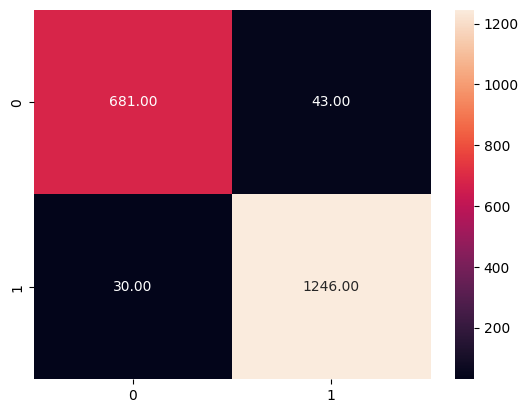

In [11]:
# Define the hyperparameters and the grid
param_grid = {
    "kernel": ["linear", "poly", "rbf"],
}

evaluate_model(
    SVC(random_state=random_state, probability=True),
    "SVC",
    param_grid,
    X_train,
    X_test,
    y_train,
    y_test,
)

KNN Model and Tuning K


Best hyperparameters that can be used => {'n_neighbors': 14}
Train Accuracy Score: 89.94
Test Accuracy Score: 87.35
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.81       724
           1       0.86      0.95      0.91      1276

    accuracy                           0.87      2000
   macro avg       0.88      0.84      0.86      2000
weighted avg       0.88      0.87      0.87      2000



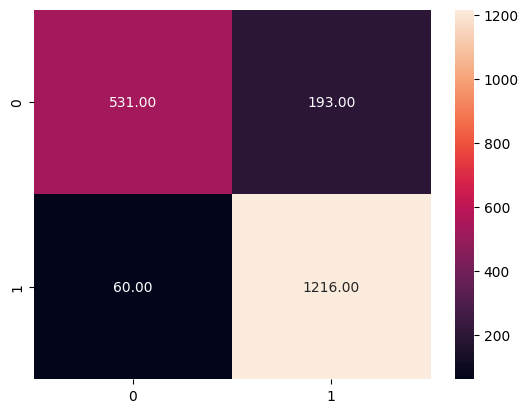

In [12]:
# Define the parameter grid
param_grid = {"n_neighbors": list(range(1, 31))}

evaluate_model(
        KNeighborsClassifier(n_jobs=-1),
        f"KNN",
        param_grid,
        X_train,
        X_test,
        y_train,
        y_test,
    )

Decision Tree Model and Tuning Depth


Best hyperparameters that can be used => {'max_depth': 9}
Train Accuracy Score: 95.0
Test Accuracy Score: 85.75
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.79      0.80       724
           1       0.88      0.90      0.89      1276

    accuracy                           0.86      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.86      0.86      0.86      2000



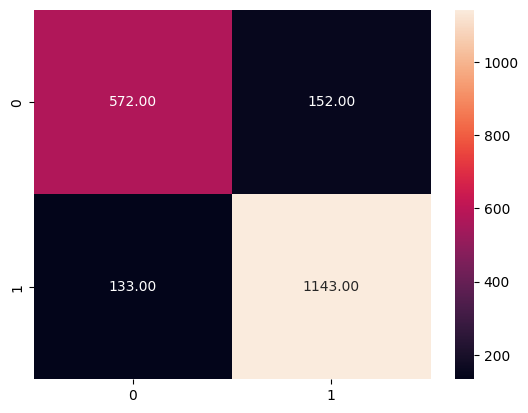

In [13]:
# Define the parameter grid
param_grid = {"max_depth": list(range(1, 21))}

evaluate_model(
       DecisionTreeClassifier(random_state=random_state),
        f"Decision_Tree",
        param_grid,
        X_train,
        X_test,
        y_train,
        y_test,
    )

In [14]:
model_df = pd.DataFrame(
    train_model_lists,
    columns=[
        "Model_Name",
        "Train_Accuracy",
        "Test_Accuracy",
        "ROC_AUC",
        "Precision",
        "Recall",
        "F1 Score",
        "Model",
    ],
)

# Prinitng all models metrics in sorted order
model_df.sort_values(by=["Recall", "F1 Score"], ascending=False)

,Model_Name,Train_Accuracy,Test_Accuracy,ROC_AUC,Precision,Recall,F1 Score,Model
0,SVC,97.47,96.35,99.48,96.34,96.35,96.34,"SVC(probability=True, random_state=42)"
1,KNN,89.94,87.35,95.14,87.59,87.35,87.02,"KNeighborsClassifier(n_jobs=-1, n_neighbors=14)"
2,Decision_Tree,95.00,85.75,87.29,85.68,85.75,85.71,"DecisionTreeClassifier(max_depth=9, random_sta..."


Hyper-parameters Tuning in ML Model Development

Hyper-parameter tuning is crucial in ML model development as it helps in optimizing the model performance by selecting the best set of parameters. Here's an overview of what we observed in this task:

- SVM: The choice of kernel significantly impacts the performance. Linear kernels are simpler but might not capture complex relationships as well as RBF or polynomial kernels.
- KNN: The number of neighbors (K) determines the bias-variance trade-off. A smaller K might lead to a more complex model with high variance, whereas a larger K might smoothen the decision boundary, increasing bias but reducing variance.
- Decision Tree: The depth of the tree controls the complexity. A deeper tree might overfit the training data, capturing noise as patterns, while a shallow tree might underfit, failing to capture important patterns in the data.


# Summary

In this report we have learnt about different models i.e. SVC, KNN and Decision Tree with usage of GridSearchCV. Here we have learnt about different libraries from python, sklearn from loading the file to the modelling and then checking metrics of different models.

# References

- https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data
- Different blogs from https://medium.com/ like
  - https://medium.com/edureka/support-vector-machine-in-python-539dca55c26a
  - https://medium.com/swlh/k-nearest-neighbor-ca2593d7a3c4
  - https://medium.com/@MrBam44/decision-trees-91f61a42c724
- https://scikit-learn.org/stable/api/sklearn.preprocessing.html
- https://scikit-learn.org/stable/api/sklearn.tree.html
- https://scikit-learn.org/stable/api/sklearn.neighbors.html
- https://scikit-learn.org/stable/api/sklearn.svm.html
